In [40]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

# =========================
# 0. 参数设置
# =========================

samples = {
    "R1_B1": {
        "condition": "NR",
        "path": "/home/workspace/MACSima/SopaRes/R1_B1/R1_B1.explorer/adata.h5ad"
    },
    "R1_D1": {
        "condition": "NR",
        "path": "/home/workspace/MACSima/SopaRes/R1_D1/ROI1.explorer/adata.h5ad"
    },
    "R2_B1": {
        "condition": "R",
        "path": "/home/workspace/MACSima/SopaRes/R2_B1/ROI1.explorer/adata.h5ad"
    },
    "R2_D1": {
        "condition": "R",
        "path": "/home/workspace/MACSima/SopaRes/R2_D1/ROI1.explorer/adata.h5ad"
    }
}

celltype_key = "cell_type"
spatial_key = "spatial"

#anchor_type = "EC"
anchor_type = 'Fibroblast'
target_types = ["CCR1+",'SPP1+', "M2", "Myeloid",'Exhaust','Memory','Naive','CART','EC']

n_neigh = 10

outdir = "/home/workspace/MACSima/SopaRes/fap_niche_result"
os.makedirs(outdir, exist_ok=True)

sns.set_theme(style="white", font="Arial", font_scale=1.1)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["figure.dpi"] = 300

ec_type = "EC"
fibroblast_type = "Fibroblast"

target_types = [
    "CCR1+", "SPP1+", "M2", "Myeloid",
    "Exhaust", "Memory", "Naive", "CART", "EC"
]

n_neigh = 10
radii = np.arange(20, 201, 20)

outdir = "/home/workspace/MACsima/SopaRes/fap_ec_adjacent_fibroblast_result"
os.makedirs(outdir, exist_ok=True)

In [36]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu

In [27]:
def extract_ec_adjacent_fibroblasts(
    adata,
    sample_id,
    condition,
    ec_type="EC",
    fibroblast_type="Fibroblast",
    celltype_key="cell_type",
    spatial_key="spatial",
    n_neigh=10
):
    if "spatial_connectivities" not in adata.obsp:
        sq.gr.spatial_neighbors(
            adata,
            coord_type="generic",
            spatial_key=spatial_key,
            n_neigh=n_neigh
        )

    ct = adata.obs[celltype_key].astype(str).values
    adj = adata.obsp["spatial_connectivities"]

    ec_idx = np.where(ct == ec_type)[0]

    fibroblast_hits = []

    for eidx in ec_idx:
        neigh_idx = adj[eidx].indices
        fib_idx = neigh_idx[ct[neigh_idx] == fibroblast_type]

        for fidx in fib_idx:
            fibroblast_hits.append({
                "sample": sample_id,
                "condition": condition,
                "ec_cell": adata.obs_names[eidx],
                "fibroblast_cell": adata.obs_names[fidx],
                "fibroblast_idx": fidx
            })

    df = pd.DataFrame(fibroblast_hits)

    if df.empty:
        return df

    # 一个 Fibroblast 可能邻近多个 EC；统计时去重，避免重复计数
    df_unique = (
        df.groupby(["sample", "condition", "fibroblast_cell", "fibroblast_idx"])
        .agg(n_adjacent_ec=("ec_cell", "nunique"))
        .reset_index()
    )

    return df_unique

In [29]:
ec_adjacent_fibroblast_results = []
adatas = {}

for sid, info in samples.items():
    print(f"Loading {sid}")
    adata = sc.read_h5ad(info["path"])

    adata.obs["sample"] = sid
    adata.obs["condition"] = info["condition"]

    if "spatial_connectivities" not in adata.obsp:
        sq.gr.spatial_neighbors(
            adata,
            coord_type="generic",
            spatial_key=spatial_key,
            n_neighs=n_neigh
        )

    adatas[sid] = adata

    df = extract_ec_adjacent_fibroblasts(
        adata=adata,
        sample_id=sid,
        condition=info["condition"],
        ec_type=ec_type,
        fibroblast_type=fibroblast_type,
        celltype_key=celltype_key,
        spatial_key=spatial_key,
        n_neigh=n_neigh
    )

    ec_adjacent_fibroblast_results.append(df)

ec_fib_df = pd.concat(ec_adjacent_fibroblast_results, ignore_index=True)

ec_fib_df.to_csv(
    os.path.join(outdir, "ec_adjacent_fibroblasts.csv"),
    index=False
)

ec_fib_df.head()

Loading R1_B1
Loading R1_D1
Loading R2_B1
Loading R2_D1


,sample,condition,fibroblast_cell,fibroblast_idx,n_adjacent_ec
0,R1_B1,NR,aaaaaani-1,216,1
1,R1_B1,NR,aaaaaban-1,269,1
2,R1_B1,NR,aaaaabej-1,329,1
3,R1_B1,NR,aaaaaboa-1,480,1
4,R1_B1,NR,aaaaacaa-1,512,1


In [30]:
def compute_niche_for_selected_fibroblasts(
    adata,
    selected_fibroblast_df,
    sample_id,
    condition,
    target_types,
    celltype_key="cell_type"
):
    ct = adata.obs[celltype_key].astype(str).values
    adj = adata.obsp["spatial_connectivities"]

    rows = []

    sample_fibs = selected_fibroblast_df[
        selected_fibroblast_df["sample"] == sample_id
    ]

    for _, fib in sample_fibs.iterrows():
        fidx = int(fib["fibroblast_idx"])

        neigh_idx = adj[fidx].indices
        neigh_types = ct[neigh_idx]

        if len(neigh_types) == 0:
            continue

        row = {
            "sample": sample_id,
            "condition": condition,
            "fibroblast_cell": fib["fibroblast_cell"],
            "n_adjacent_ec": fib["n_adjacent_ec"],
            "n_neighbors": len(neigh_types)
        }

        for target in target_types:
            row[target] = np.mean(neigh_types == target)

        rows.append(row)

    return pd.DataFrame(rows)

In [31]:
niche_results = []

for sid, adata in adatas.items():
    condition = samples[sid]["condition"]

    df = compute_niche_for_selected_fibroblasts(
        adata=adata,
        selected_fibroblast_df=ec_fib_df,
        sample_id=sid,
        condition=condition,
        target_types=target_types,
        celltype_key=celltype_key
    )

    niche_results.append(df)

ec_adj_fib_niche_df = pd.concat(niche_results, ignore_index=True)

ec_adj_fib_niche_df.to_csv(
    os.path.join(outdir, "ec_adjacent_fibroblast_niche_per_cell.csv"),
    index=False
)

ec_adj_fib_niche_df.head()

,sample,condition,fibroblast_cell,n_adjacent_ec,n_neighbors,CCR1+,SPP1+,M2,Myeloid,Exhaust,Memory,Naive,CART,EC
0,R1_B1,NR,aaaaaani-1,1,10,0.100000,0.0,0.100000,0.100,0.200000,0.000000,0.200000,0.0,0.100000
1,R1_B1,NR,aaaaaban-1,1,8,0.125000,0.0,0.125000,0.125,0.250000,0.125000,0.000000,0.0,0.125000
2,R1_B1,NR,aaaaabej-1,1,13,0.000000,0.0,0.153846,0.000,0.076923,0.461538,0.230769,0.0,0.076923
3,R1_B1,NR,aaaaaboa-1,1,12,0.083333,0.0,0.750000,0.000,0.083333,0.000000,0.000000,0.0,0.083333
4,R1_B1,NR,aaaaacaa-1,1,11,0.272727,0.0,0.000000,0.000,0.272727,0.181818,0.000000,0.0,0.090909


In [32]:
stats = []

for target in target_types:
    nr = ec_adj_fib_niche_df.loc[
        ec_adj_fib_niche_df["condition"] == "NR", target
    ].dropna()

    r = ec_adj_fib_niche_df.loc[
        ec_adj_fib_niche_df["condition"] == "R", target
    ].dropna()

    if len(nr) > 0 and len(r) > 0:
        stat, p = mannwhitneyu(nr, r, alternative="two-sided")
    else:
        stat, p = np.nan, np.nan

    stats.append({
        "target_celltype": target,
        "NR_mean": nr.mean(),
        "R_mean": r.mean(),
        "NR_n_ec_adjacent_fibroblast": len(nr),
        "R_n_ec_adjacent_fibroblast": len(r),
        "p_value": p
    })

stats_df = pd.DataFrame(stats).sort_values("p_value")

stats_df.to_csv(
    os.path.join(outdir, "ec_adjacent_fibroblast_niche_stats.csv"),
    index=False
)

stats_df

,target_celltype,NR_mean,R_mean,NR_n_ec_adjacent_fibroblast,R_n_ec_adjacent_fibroblast,p_value
3,Myeloid,0.022968,0.051139,910,654,3.394643e-14
1,SPP1+,0.033843,0.056567,910,654,2.051056e-10
6,Naive,0.094579,0.123007,910,654,2.388666e-06
4,Exhaust,0.072121,0.047666,910,654,1.951357e-04
0,CCR1+,0.053195,0.053510,910,654,4.577131e-02
2,M2,0.076585,0.074959,910,654,2.032770e-01
8,EC,0.145777,0.149158,910,654,5.201164e-01
5,Memory,0.096376,0.095260,910,654,9.479433e-01
7,CART,0.000000,0.000000,910,654,1.000000e+00


/tmp/ipykernel_2477078/4223404289.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

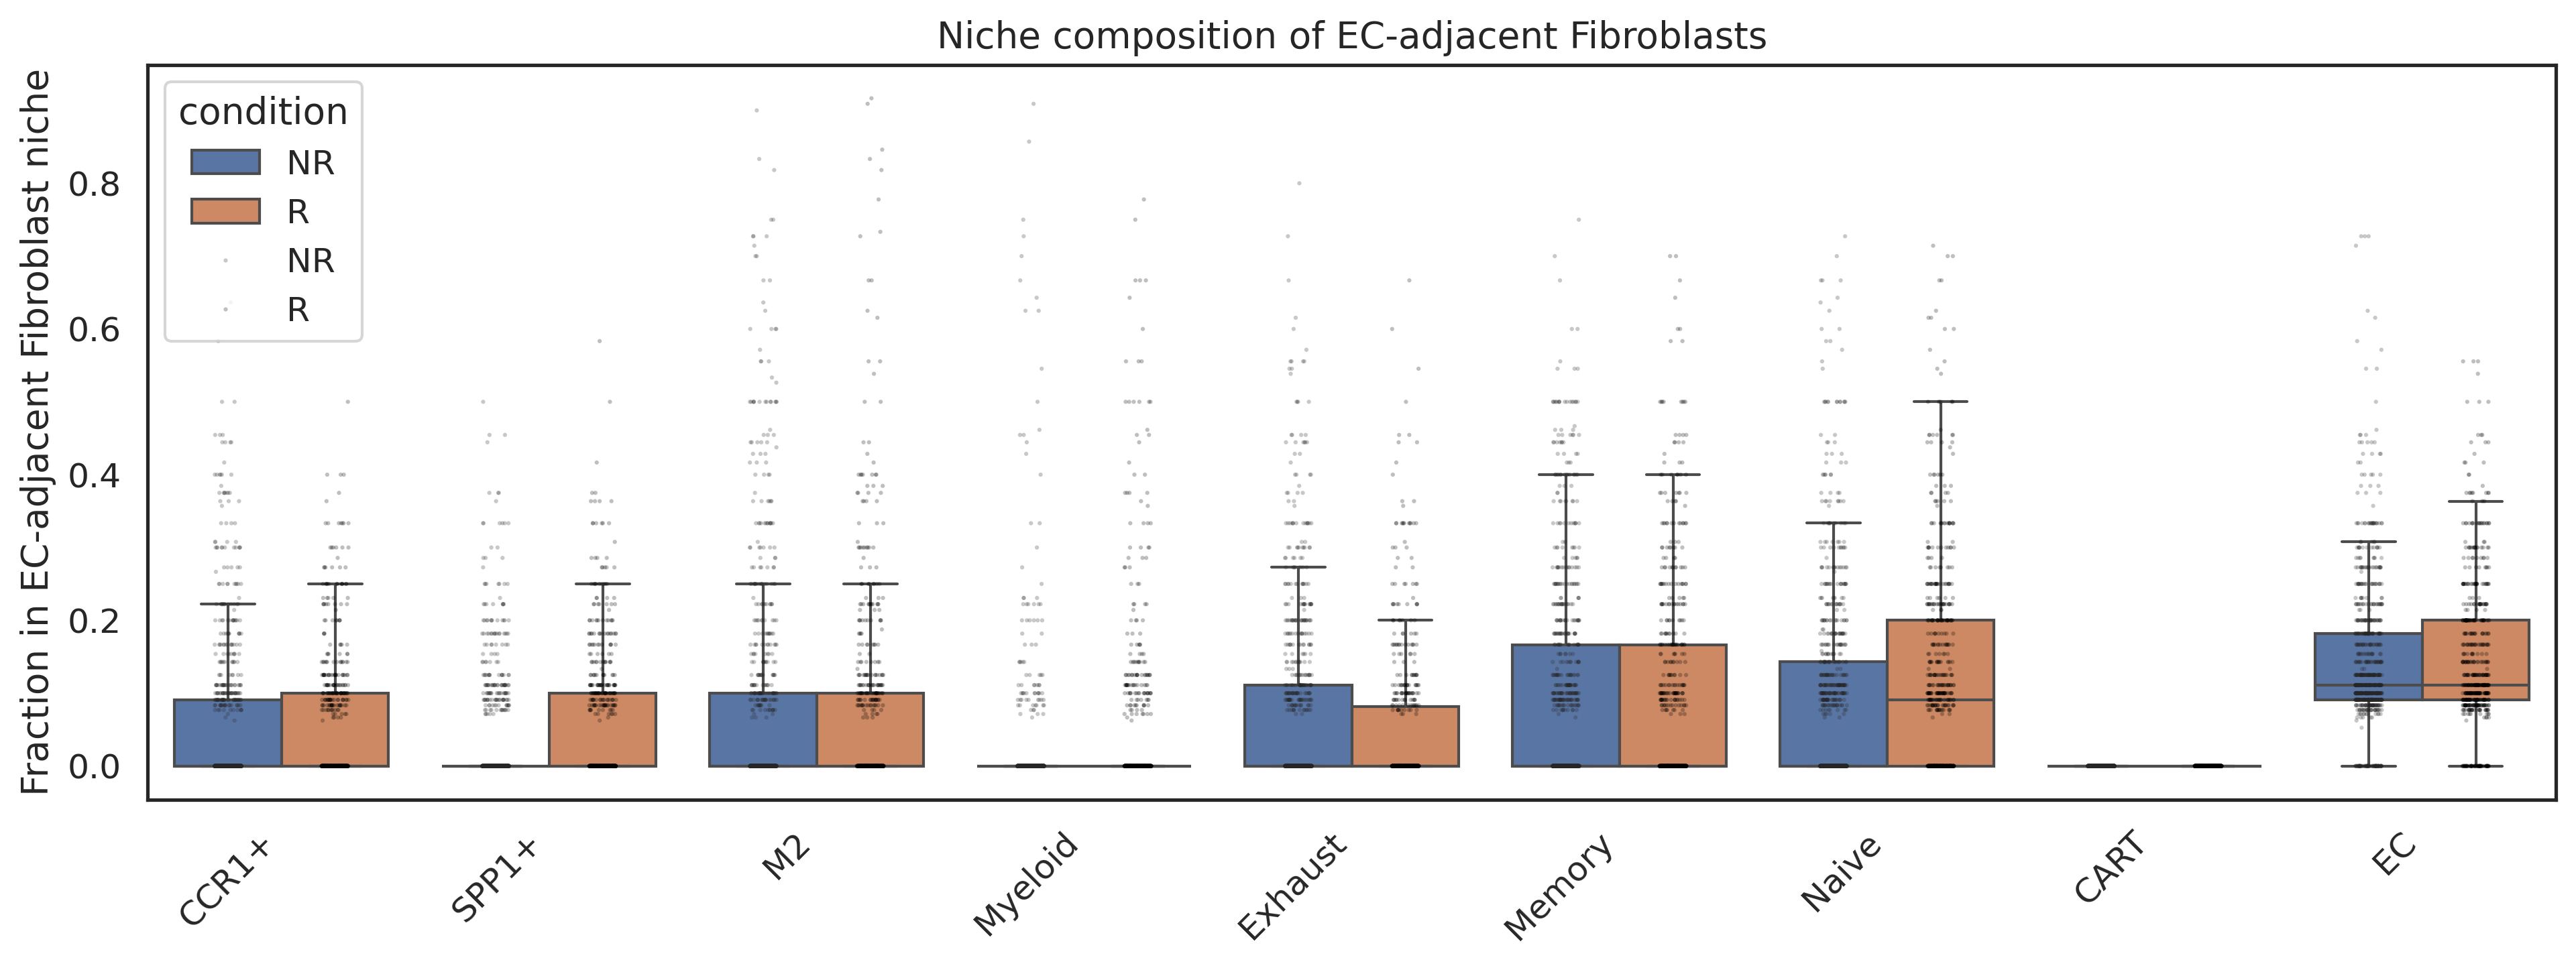

In [41]:
plot_df = ec_adj_fib_niche_df.melt(
    id_vars=["sample", "condition", "fibroblast_cell", "n_adjacent_ec"],
    value_vars=target_types,
    var_name="target_celltype",
    value_name="neighbor_fraction"
)

plt.figure(figsize=(13, 5))

sns.boxplot(
    data=plot_df,
    x="target_celltype",
    y="neighbor_fraction",
    hue="condition",
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x="target_celltype",
    y="neighbor_fraction",
    hue="condition",
    dodge=True,
    size=1.5,
    alpha=0.25,
    color="black"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction in EC-adjacent Fibroblast niche")
plt.xlabel("")
plt.title("Niche composition of EC-adjacent Fibroblasts")
plt.tight_layout()

plt.savefig(
    os.path.join(outdir, "ec_adjacent_fibroblast_niche_boxplot.pdf")
)

plt.show()

In [34]:
def compute_ec_adjacent_fibroblast_proximity_curve(
    adata,
    selected_fibroblast_df,
    sample_id,
    condition,
    target_types,
    radii,
    celltype_key="cell_type",
    spatial_key="spatial"
):
    coords = adata.obsm[spatial_key]
    ct = adata.obs[celltype_key].astype(str).values
    tree = cKDTree(coords)

    sample_fibs = selected_fibroblast_df[
        selected_fibroblast_df["sample"] == sample_id
    ]

    rows = []

    for _, fib in sample_fibs.iterrows():
        fidx = int(fib["fibroblast_idx"])
        center = coords[fidx]

        for radius in radii:
            neigh_idx = tree.query_ball_point(center, r=radius)

            # 去掉自己
            neigh_idx = [i for i in neigh_idx if i != fidx]

            if len(neigh_idx) == 0:
                continue

            neigh_types = ct[neigh_idx]

            for target in target_types:
                rows.append({
                    "sample": sample_id,
                    "condition": condition,
                    "fibroblast_cell": fib["fibroblast_cell"],
                    "n_adjacent_ec": fib["n_adjacent_ec"],
                    "radius": radius,
                    "target_celltype": target,
                    "fraction": np.mean(neigh_types == target),
                    "count": np.sum(neigh_types == target),
                    "total_neighbors": len(neigh_types)
                })

    return pd.DataFrame(rows)

In [37]:
curve_results = []

for sid, adata in adatas.items():
    condition = samples[sid]["condition"]

    df = compute_ec_adjacent_fibroblast_proximity_curve(
        adata=adata,
        selected_fibroblast_df=ec_fib_df,
        sample_id=sid,
        condition=condition,
        target_types=target_types,
        radii=radii,
        celltype_key=celltype_key,
        spatial_key=spatial_key
    )

    curve_results.append(df)

curve_df = pd.concat(curve_results, ignore_index=True)

curve_df.to_csv(
    os.path.join(outdir, "ec_adjacent_fibroblast_proximity_curve.csv"),
    index=False
)

curve_df.head()

,sample,condition,fibroblast_cell,n_adjacent_ec,radius,target_celltype,fraction,count,total_neighbors
0,R1_B1,NR,aaaaaani-1,1,40,CCR1+,0.000000,0,3
1,R1_B1,NR,aaaaaani-1,1,40,SPP1+,0.000000,0,3
2,R1_B1,NR,aaaaaani-1,1,40,M2,0.000000,0,3
3,R1_B1,NR,aaaaaani-1,1,40,Myeloid,0.333333,1,3
4,R1_B1,NR,aaaaaani-1,1,40,Exhaust,0.333333,1,3


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

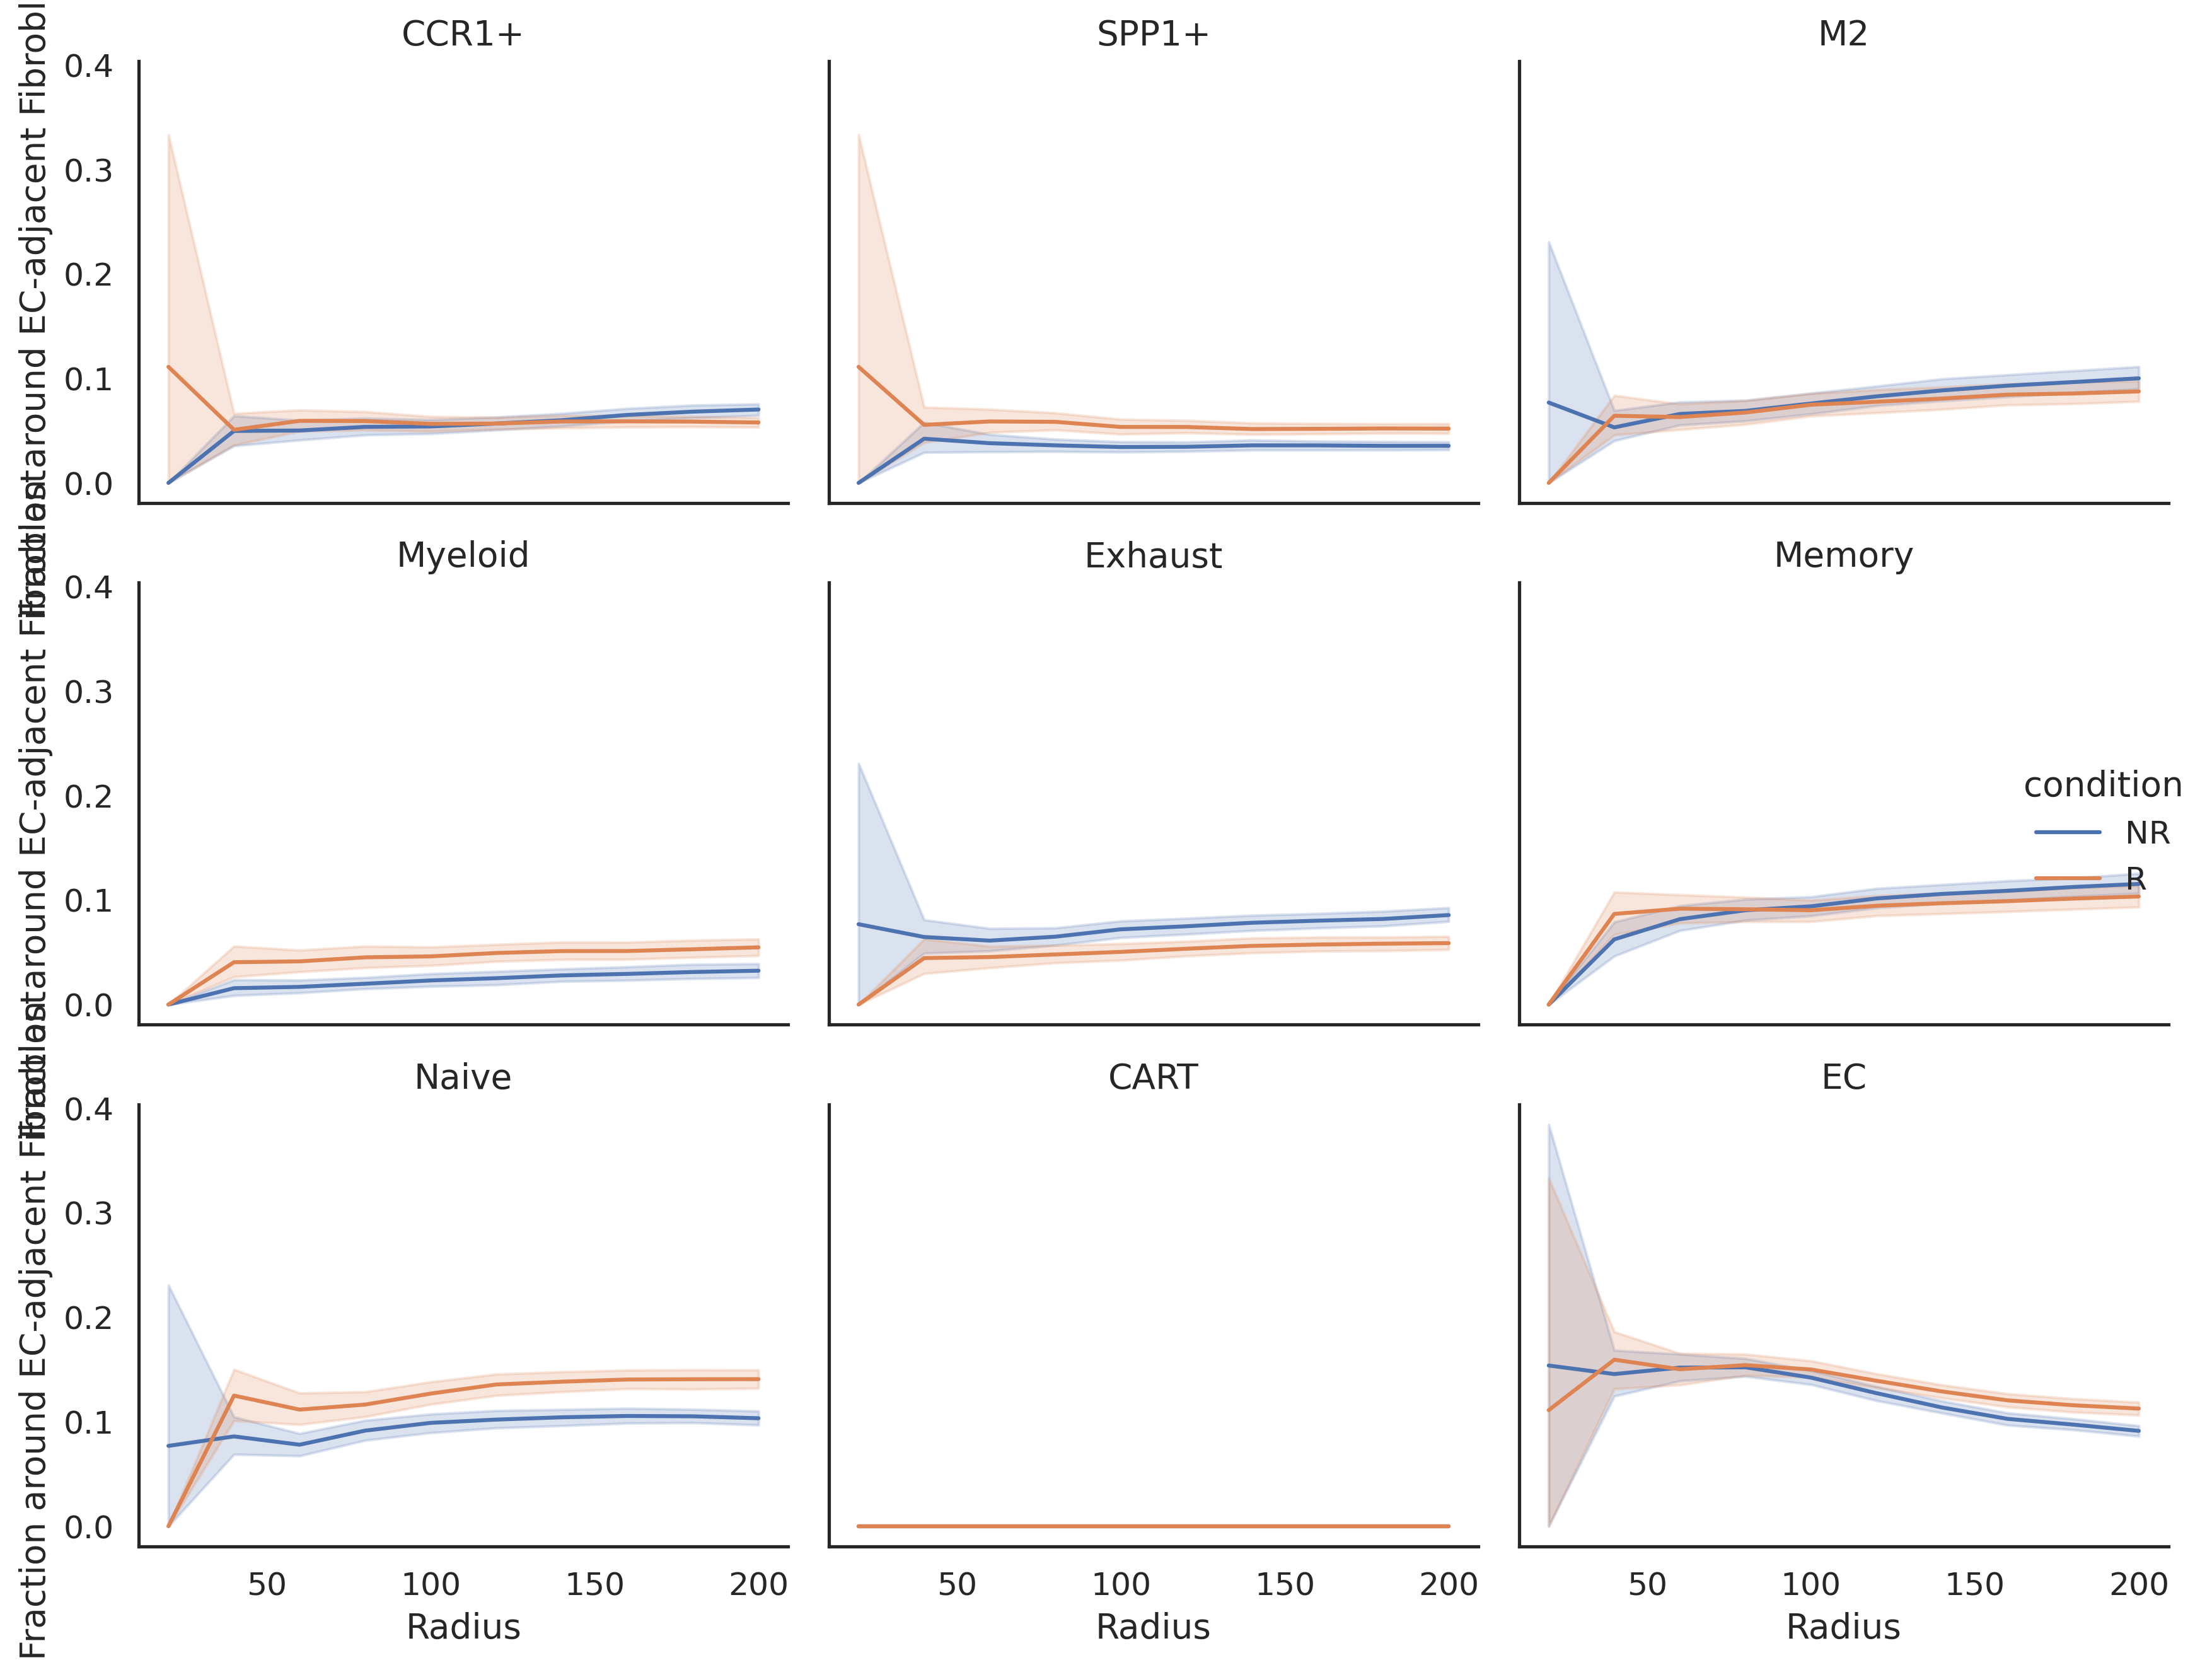

In [38]:
g = sns.relplot(
    data=curve_df,
    x="radius",
    y="fraction",
    hue="condition",
    col="target_celltype",
    col_wrap=3,
    kind="line",
    errorbar=("ci", 95),
    height=3,
    aspect=1.2
)

g.set_axis_labels("Radius", "Fraction around EC-adjacent Fibroblast")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig(
    os.path.join(outdir, "ec_adjacent_fibroblast_proximity_curve_fraction.pdf")
)

plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

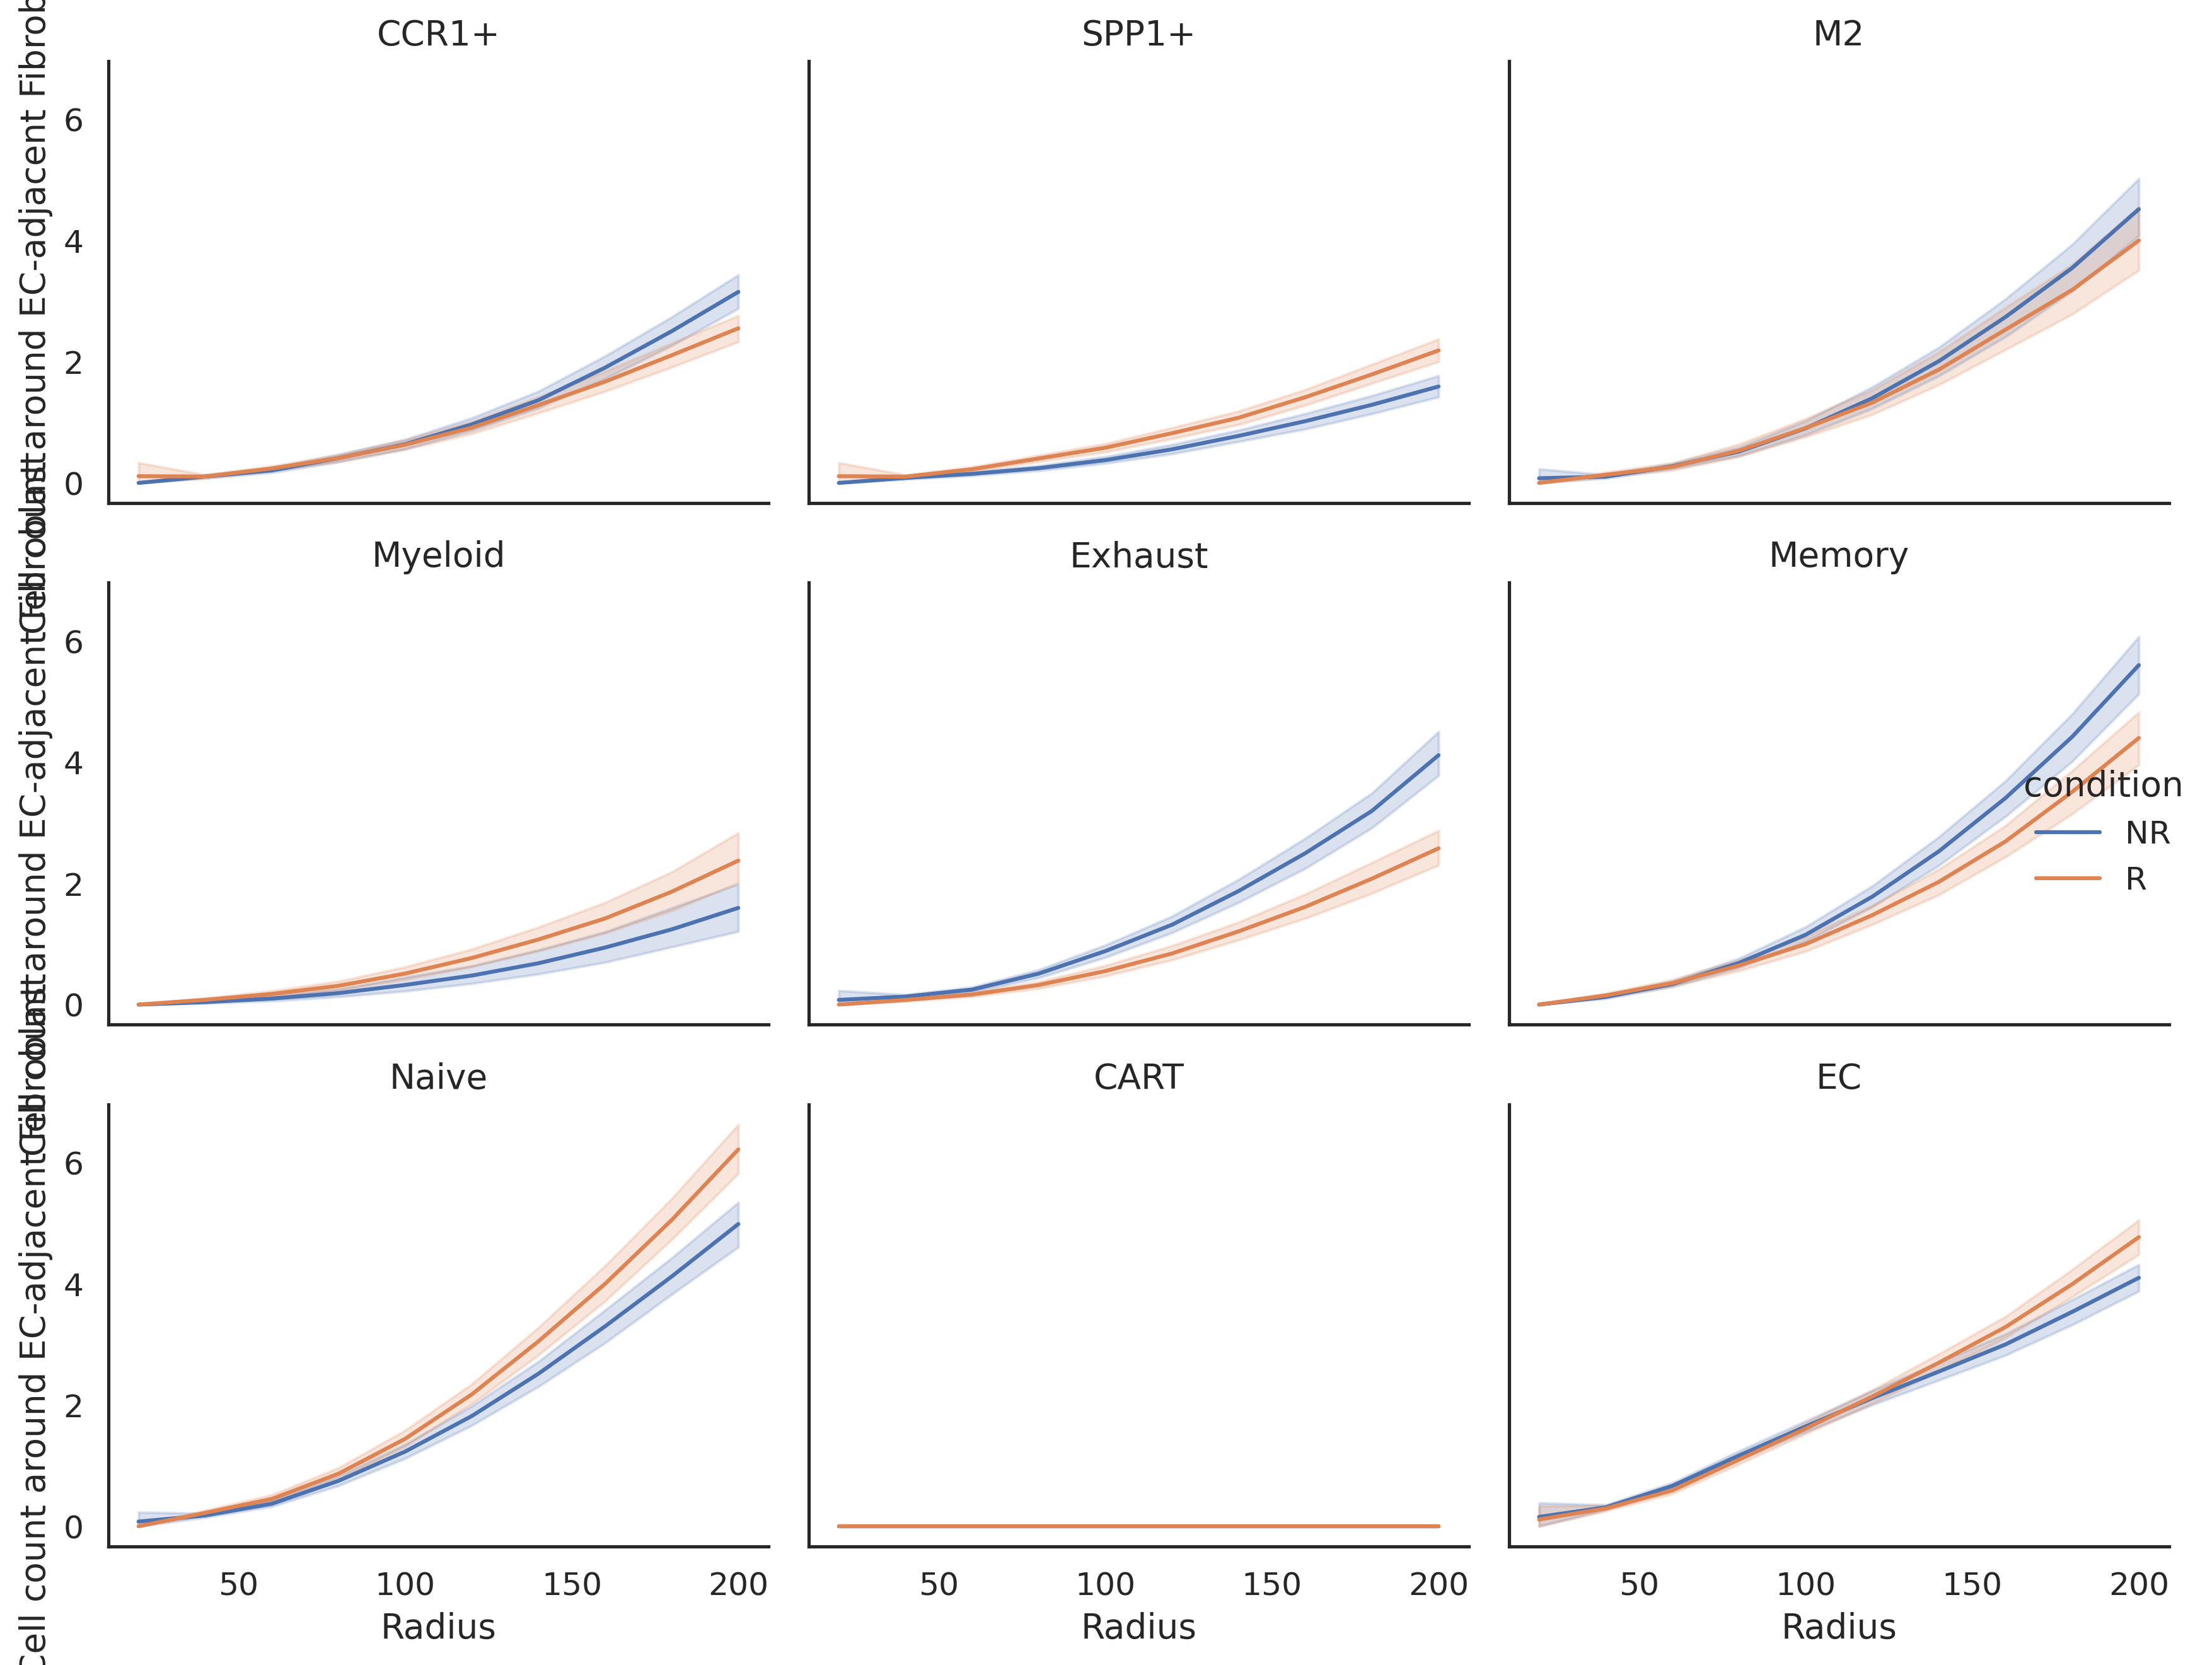

In [39]:
g = sns.relplot(
    data=curve_df,
    x="radius",
    y="count",
    hue="condition",
    col="target_celltype",
    col_wrap=3,
    kind="line",
    errorbar=("ci", 95),
    height=3,
    aspect=1.2
)

g.set_axis_labels("Radius", "Cell count around EC-adjacent Fibroblast")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig(
    os.path.join(outdir, "ec_adjacent_fibroblast_proximity_curve_count.pdf")
)

plt.show()

In [14]:
# =========================
# 1. 批量读取 + 统计 EC 邻域
# =========================

all_ec_rows = []

for sample, info in samples.items():
    print(f"Processing {sample} ...")

    adata = sc.read_h5ad(info["path"])

    adata.obs["sample"] = sample
    adata.obs["condition"] = info["condition"]

    if celltype_key not in adata.obs.columns:
        raise ValueError(f"{sample}: adata.obs 中找不到 {celltype_key}")

    if spatial_key not in adata.obsm.keys():
        raise ValueError(f"{sample}: adata.obsm 中找不到 {spatial_key}")

    # 重新构建空间邻接，保证每个 sample 独立计算
    sq.gr.spatial_neighbors(
        adata,
        coord_type="generic",
        spatial_key=spatial_key,
        n_neighs=n_neigh
    )

    A = adata.obsp["spatial_connectivities"].tocsr()
    ct = adata.obs[celltype_key].astype(str).values

    ec_idx = np.where(ct == anchor_type)[0]

    print(f"  CAF number: {len(ec_idx)}")
    print(f"  Cell types: {adata.obs[celltype_key].unique().tolist()}")

    for i in ec_idx:
        neigh = A[i].nonzero()[1]
        neigh_types = ct[neigh]

        row = {
            "sample": sample,
            "condition": info["condition"],
            "CAF_cell": adata.obs_names[i],
            "total_neighbors": len(neigh)
        }

        for t in target_types:
            row[t] = np.sum(neigh_types == t)

        all_ec_rows.append(row)

df_ec = pd.DataFrame(all_ec_rows)

# 每个 EC 的邻域比例
for t in target_types:
    df_ec[f"{t}_prop"] = df_ec[t] / df_ec["total_neighbors"]

df_ec.to_csv(
    os.path.join(outdir, "CAF_neighbor_per_cell.csv"),
    index=False
)

df_ec.head()

Processing R1_B1 ...
  CAF number: 4123
  Cell types: ['CD4T Cells', 'M2', 'Naive', 'Myeloid', 'Fibroblast', 'Exhaust', 'Memory', 'EC', 'CCR1+', 'SPP1+', 'CART cell']
Processing R1_D1 ...
  CAF number: 1717
  Cell types: ['Myeloid', 'CD4T Cells', 'CART cell', 'CCR1+', 'M2', 'SPP1+', 'Exhaust', 'Naive', 'Memory', 'EC', 'Fibroblast']
Processing R2_B1 ...
  CAF number: 1393
  Cell types: ['M2', 'Myeloid', 'CART cell', 'CCR1+', 'Naive', 'Memory', 'Exhaust', 'CD4T Cells', 'EC', 'Fibroblast', 'SPP1+']
Processing R2_D1 ...
  CAF number: 1422
  Cell types: ['M2', 'CCR1+', 'CD4T Cells', 'EC', 'Naive', 'CART cell', 'Myeloid', 'Fibroblast', 'Exhaust', 'Memory', 'SPP1+']


,sample,condition,CAF_cell,total_neighbors,CCR1+,SPP1+,M2,Myeloid,Exhaust,Memory,...,EC,CCR1+_prop,SPP1+_prop,M2_prop,Myeloid_prop,Exhaust_prop,Memory_prop,Naive_prop,CART_prop,EC_prop
0,R1_B1,NR,aaaaaabp-1,13,0,0,9,0,0,0,...,0,0.0,0.0,0.692308,0.0,0.0,0.0,0.153846,0.0,0.0
1,R1_B1,NR,aaaaaaci-1,7,0,0,6,0,0,0,...,0,0.0,0.0,0.857143,0.0,0.0,0.0,0.000000,0.0,0.0
2,R1_B1,NR,aaaaaack-1,8,0,0,7,0,0,0,...,0,0.0,0.0,0.875000,0.0,0.0,0.0,0.125000,0.0,0.0
3,R1_B1,NR,aaaaaadi-1,5,0,0,0,1,0,0,...,0,0.0,0.0,0.000000,0.2,0.0,0.0,0.000000,0.0,0.0
4,R1_B1,NR,aaaaaadj-1,8,0,0,8,0,0,0,...,0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0


In [15]:
# =========================
# 2. 按 sample 汇总
# =========================

sample_rows = []

for sample, sub in df_ec.groupby("sample"):
    total_neighbors = sub["total_neighbors"].sum()

    row = {
        "sample": sample,
        "condition": sub["condition"].iloc[0],
        "n_CAF": sub.shape[0],
        "total_neighbors": total_neighbors
    }

    for t in target_types:
        row[f"{t}_count"] = sub[t].sum()
        row[f"{t}_prop"] = sub[t].sum() / total_neighbors

    sample_rows.append(row)

df_sample = pd.DataFrame(sample_rows)

df_sample["condition"] = pd.Categorical(
    df_sample["condition"],
    categories=["NR", "R"],
    ordered=True
)

df_sample = df_sample.sort_values(["condition", "sample"])

df_sample.to_csv(
    os.path.join(outdir, "CAF_neighbor_sample_summary.csv"),
    index=False
)

df_sample

,sample,condition,n_CAF,total_neighbors,CCR1+_count,CCR1+_prop,SPP1+_count,SPP1+_prop,M2_count,M2_prop,...,Exhaust_count,Exhaust_prop,Memory_count,Memory_prop,Naive_count,Naive_prop,CART_count,CART_prop,EC_count,EC_prop
0,R1_B1,NR,4123,41641,1520,0.036502,817,0.019620,5209,0.125093,...,2695,0.064720,3103,0.074518,3867,0.092865,0,0.0,628,0.015081
1,R1_D1,NR,1717,17425,1154,0.066227,933,0.053544,1950,0.111908,...,2046,0.117418,1745,0.100143,682,0.039139,0,0.0,793,0.045509
2,R2_B1,R,1393,13963,551,0.039461,868,0.062164,808,0.057867,...,755,0.054071,1115,0.079854,1032,0.073910,0,0.0,471,0.033732
3,R2_D1,R,1422,14232,575,0.040402,729,0.051223,1491,0.104764,...,1411,0.099143,2268,0.159359,755,0.053049,0,0.0,545,0.038294


In [16]:
# =========================
# 3. 统计检验
#    n=2/组，p value 仅作为辅助
# =========================

stats_rows = []

for t in target_types:
    col = f"{t}_prop"

    nr = df_sample.loc[df_sample["condition"] == "NR", col].dropna()
    r = df_sample.loc[df_sample["condition"] == "R", col].dropna()

    stat, p = mannwhitneyu(nr, r, alternative="two-sided")

    stats_rows.append({
        "cell_type": t,
        "NR_mean": nr.mean(),
        "R_mean": r.mean(),
        "NR_values": ";".join(map(str, nr.values)),
        "R_values": ";".join(map(str, r.values)),
        "log2FC_R_vs_NR": np.log2((r.mean() + 1e-9) / (nr.mean() + 1e-9)),
        "p_value": p
    })

df_stats = pd.DataFrame(stats_rows)

df_stats.to_csv(
    os.path.join(outdir, "CAF_neighbor_statistics.csv"),
    index=False
)

df_stats

,cell_type,NR_mean,R_mean,NR_values,R_values,log2FC_R_vs_NR,p_value
0,CCR1+,0.051365,0.039932,0.03650248553108715;0.06622668579626972,0.039461433789300296;0.04040191118605958,-0.363241,1.000000
1,SPP1+,0.036582,0.056693,0.019620085972959344;0.053543758967001434,0.06216429134140228;0.05122259696458684,0.632051,0.666667
2,M2,0.118501,0.081316,0.12509305732331116;0.11190817790530846,0.05786722051135143;0.10476391231028667,-0.543291,0.333333
3,Myeloid,0.043761,0.064005,0.02118104752527557;0.06634146341463415,0.11838430136790089;0.00962619449128724,0.548536,1.000000
4,Exhaust,0.091069,0.076607,0.06471986743834202;0.11741750358680057,0.05407147461147318;0.09914277684092186,-0.249476,0.666667
5,Memory,0.087331,0.119607,0.07451790302826541;0.10014347202295552,0.07985389959177827;0.15935919055649242,0.453736,0.666667
6,Naive,0.066002,0.063480,0.09286520496625922;0.03913916786226686,0.0739096182768746;0.05304946599213041,-0.056222,1.000000
7,CART,0.000000,0.000000,0.0;0.0,0.0;0.0,0.000000,1.000000
8,EC,0.030295,0.036013,0.015081290074686006;0.04550932568149211,0.03373200601589916;0.03829398538504778,0.249423,1.000000


In [22]:
import glob
base_dir = "/home/workspace/MACsima/SopaRes"

h5ad_files = glob.glob(base_dir + "/*/*.explorer/adata.h5ad")

ValueError: The palette dictionary is missing keys: {'EC', 'Naive', 'CART', 'Memory', 'Myeloid', 'SPP1+'}

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

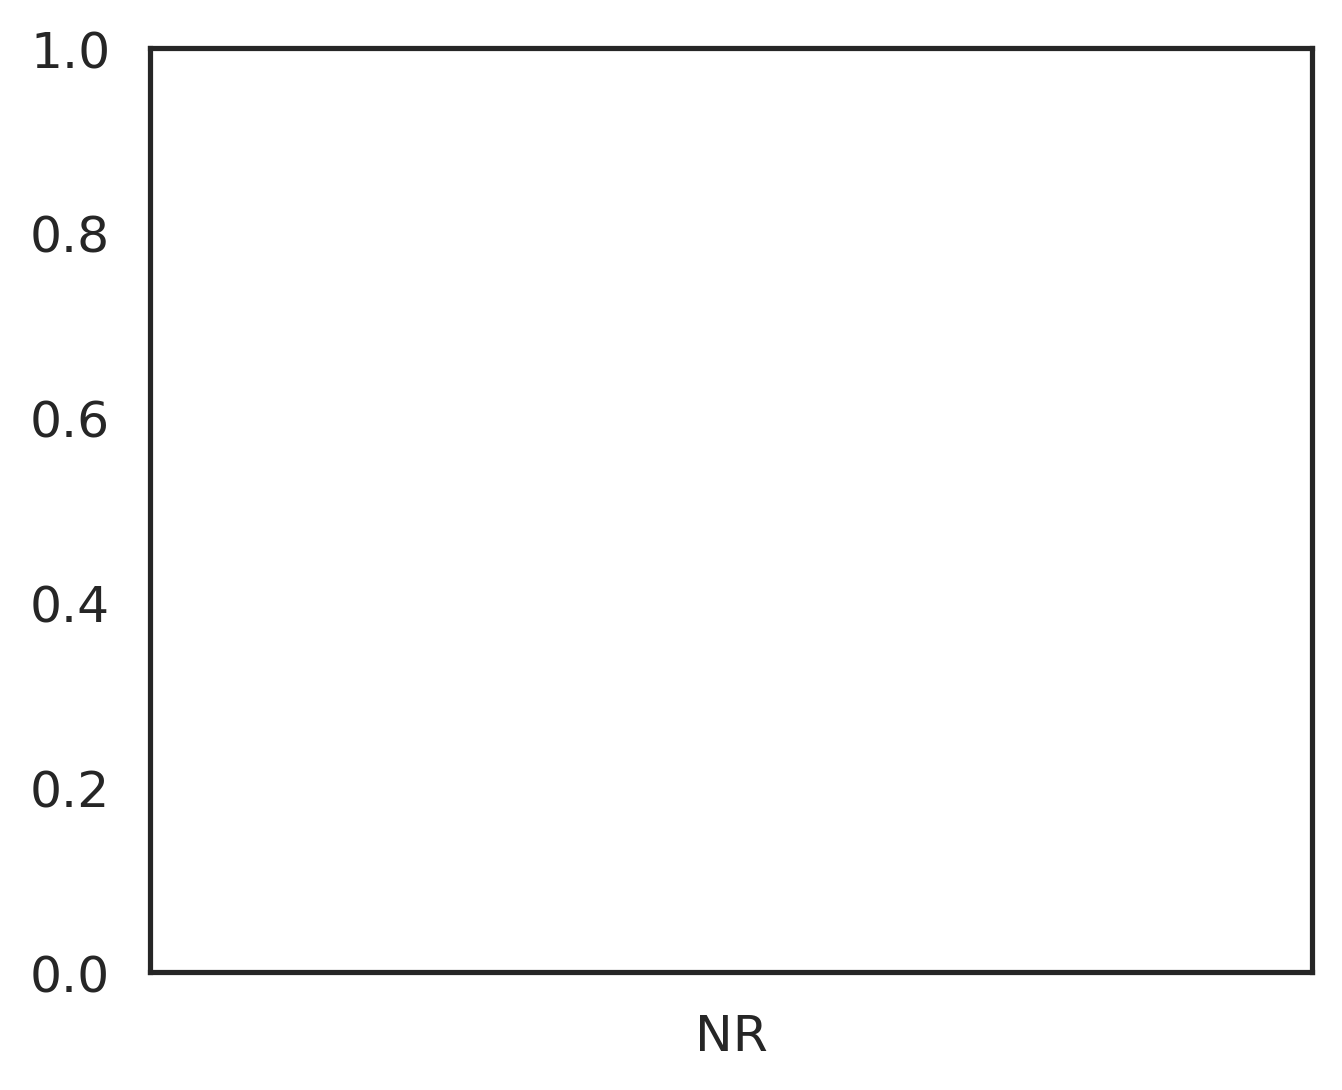

In [25]:
# =========================
# 4. 发表级图 1：
#    EC niche NR vs R 曲线图
# =========================

plot_df = df_sample.melt(
    id_vars=["sample", "condition"],
    value_vars=[f"{t}_prop" for t in target_types],
    var_name="cell_type",
    value_name="proportion"
)

plot_df["cell_type"] = plot_df["cell_type"].str.replace("_prop", "", regex=False)

plot_df_all = plot_df.copy()

plot_df = plot_df[plot_df["cell_type"].isin(target_types)]

palette = {
    "CCR1+": "#D62728",
    "M2": "#1F77B4",
    "Exhaust": "#2CA02C"
}

fig, ax = plt.subplots(figsize=(5.0, 4.0))

sns.pointplot(
    data=plot_df,
    x="condition",
    y="proportion",
    hue="cell_type",
    order=["NR", "R"],
    palette=palette,
    dodge=0.28,
    markers="o",
    linestyles="-",
    linewidth=2.2,
    errorbar="se",
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="condition",
    y="proportion",
    hue="cell_type",
    order=["NR", "R"],
    palette=palette,
    dodge=True,
    size=6,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5,
    legend=False,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Proportion in EC neighborhood")
ax.set_title("CAF niche composition", fontsize=14, weight="bold")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()
plt.tight_layout()

fig.savefig(os.path.join(outdir, "Fig1_CAF_niche_lineplot.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(outdir, "Fig1_CAF_niche_lineplot.png"), dpi=600, bbox_inches="tight")
fig.savefig(os.path.join(outdir, "Fig1_CAF_niche_lineplot.svg"), bbox_inches="tight")

plt.show()

In [24]:
plot_df

,sample,condition,cell_type,proportion
0,R1_B1,NR,CCR1+,0.036502
1,R1_D1,NR,CCR1+,0.066227
2,R2_B1,R,CCR1+,0.039461
3,R2_D1,R,CCR1+,0.040402
4,R1_B1,NR,SPP1+,0.019620
5,R1_D1,NR,SPP1+,0.053544
6,R2_B1,R,SPP1+,0.062164
7,R2_D1,R,SPP1+,0.051223
8,R1_B1,NR,M2,0.125093
9,R1_D1,NR,M2,0.111908
